# ♟️ MicroCNN Domain Classifier Training & Benchmarking Notebook

**Target:** Train, validate, and test an ultra-compact **MicroCNN** neural classifier ($< 1.5\text{ MB}$ ONNX, sub-$2.5\text{ ms}$ CPU inference, sub-$0.4\text{ ms}$ GPU inference, $>99.5\%$ accuracy) for **US-3.1.2**.

### Bulletproof Domain Classifier Features:
- **Aspect-Ratio Preserving Letterboxing**: Keeps chessboard tiles square, eliminating artificial perspective distortion.
- **Synthetic Full-UI Canvas Augmentation**: Trains on realistic Chess.com & Lichess browser/app windows (sidebars, clocks, avatars, eval bars).
- **Real Physical Boards (3,680 authentic camera photos)**: Multi-angle photos of wooden and plastic sets under varied room lighting.
- **Real Digital Boards (4,750+ authentic digital screenshots)**: Authentic multi-theme screenshots from Hugging Face / Chess.com / Lichess.
- **Theme & Color Jitter**: $\pm 180^\circ$ HSV hue rotation, saturation scaling, and move highlight overlays.
- **Full Epoch Telemetry Logging**: Live ASCII Scoreboard Table, 4-Panel Real-Time Dashboard, and JSONL disk persistence.

In [1]:
# 1. Environment, Autoreload & GPU Hardware Initialization
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import logging
import shutil
import importlib
from pathlib import Path

# Setup clean logging format
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("domain_classifier")

# Ensure project root is detected and set as current working directory
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import math
import random
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from IPython.display import display

import src.domain_classifier.train_micro_cnn as train_module
importlib.reload(train_module)
from src.domain_classifier.train_micro_cnn import (
    generate_synthetic_digital_board,
    generate_synthetic_physical_photo,
    generate_synthetic_screen_recapture,
    apply_jpeg_compression,
    apply_digital_theme_jitter,
    apply_synthetic_browser_ui,
    letterbox_image,
    ChessDomainDataset,
    TrainingTelemetryLogger,
    EpochTelemetry,
)
from src.dataset import DatasetRegistry
from src.domain_classifier.micro_cnn import MicroCNN, build_domain_classifier_model
from src.domain_classifier.neural_classifier import NeuralDomainClassifier
from src.domain_classifier.heuristic_screener import StatisticalHeuristicsScreener
from src.schemas.contracts import DomainType

# Hardware Acceleration Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # Enable fast cuDNN kernel autotuning
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    logger.info(f"GPU Acceleration ACTIVE: {gpu_name} ({vram_gb:.2f} GB VRAM)")
    logger.info(f"CUDA Version: {torch.version.cuda}, cuDNN: {torch.backends.cudnn.version()}")
else:
    logger.info("Running on CPU")

logger.info(f"Project Root: {project_root.resolve()}")
logger.info(f"ONNX Runtime Providers: {ort.get_available_providers()}")

16:13:23 [INFO] GPU Acceleration ACTIVE: NVIDIA GeForce RTX 5060 Ti (15.93 GB VRAM)
16:13:23 [INFO] CUDA Version: 12.8, cuDNN: 91900
16:13:23 [INFO] Project Root: C:\coding\chess_ml
16:13:23 [INFO] ONNX Runtime Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


## 2. Ingesting Real Digital & Real Physical Datasets with `tqdm`

Verifies and standardizes:
1. **Real Physical Boards**: ~3,680 camera photos of wooden/plastic chess sets (`real_physical_boards`).
2. **Real Digital Boards**: ~4,750 authentic multi-theme screenshots (`huggingface_digital` - MohammedHemed).

In [2]:
import shutil
from pathlib import Path
from tqdm.auto import tqdm
from src.dataset import DatasetRegistry

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# ---------------------------------------------------------------------------
# 1. Download & Standardize Real Physical Camera Dataset (~213 MB)
# ---------------------------------------------------------------------------
print("📥 [1/2] Ingesting Real Physical Camera Photographs Dataset (213 MB):")
phys_dl = DatasetRegistry.get_downloader("real_physical_boards")
raw_phys_dir = phys_dl.download(project_root / "data" / "raw" / "physical")

standardized_phys_dir = project_root / "data" / "standardized" / "physical" / "images"
standardized_phys_dir.mkdir(parents=True, exist_ok=True)

raw_phys_images = list(raw_phys_dir.rglob("*.jpg")) + list(raw_phys_dir.rglob("*.png"))
print(f"📦 Discovered {len(raw_phys_images)} real camera photos.")

for img_path in tqdm(raw_phys_images, desc="Standardizing Real Physical Images", unit="img"):
    dest_path = standardized_phys_dir / f"real_{img_path.name}"
    if not dest_path.exists():
        shutil.copy2(img_path, dest_path)

# ---------------------------------------------------------------------------
# 2. Download & Standardize Real Digital Screenshots Dataset (~1.4 GB)
# ---------------------------------------------------------------------------
print("\n📥 [2/2] Ingesting Real Digital Chessboard Screenshots Dataset (Hugging Face 1.4 GB):")
dig_dl = DatasetRegistry.get_downloader("huggingface_digital")
raw_dig_dir = dig_dl.download(project_root / "data" / "raw" / "digital")

standardized_dig_dir = project_root / "data" / "standardized" / "digital" / "images"
standardized_dig_dir.mkdir(parents=True, exist_ok=True)

# Discover extracted digital images across train/val/test splits
raw_dig_images = list(raw_dig_dir.rglob("*.jpg")) + list(raw_dig_dir.rglob("*.png")) + list(raw_dig_dir.rglob("*.jpeg"))
print(f"📦 Discovered {len(raw_dig_images)} real digital screenshots in {raw_dig_dir}")

# Standardize a balanced set (e.g. up to 5,000 diverse digital images) into standardized directory
max_digital_to_copy = min(len(raw_dig_images), 5000)
for img_path in tqdm(raw_dig_images[:max_digital_to_copy], desc="Standardizing Real Digital Images", unit="img"):
    dest_path = standardized_dig_dir / f"real_dig_{img_path.name}"
    if not dest_path.exists():
        shutil.copy2(img_path, dest_path)

digital_dir = standardized_dig_dir
physical_dir = standardized_phys_dir

real_digital_files = list(digital_dir.glob("*.*"))
real_physical_files = list(physical_dir.glob("*.*"))

print("=" * 65)
print(f"✅ Total Standardized Real Digital Images:  {len(real_digital_files):,}")
print(f"✅ Total Standardized Real Physical Images: {len(real_physical_files):,}")
print("=" * 65)

16:13:23 [INFO] === Fetching Real Physical Chessboards Camera Dataset [dataset_zip] ===
16:13:23 [INFO] File already exists and verified: chessboard-dataset-yolo.zip


📥 [1/2] Ingesting Real Physical Camera Photographs Dataset (213 MB):


📦 Extracting chessboard-dataset-yolo.zip:   0%|          | 0/7369 [00:00<?, ?file/s]

16:13:29 [INFO] Extracted 7363 files to C:\coding\chess_ml\data\raw\physical\real_physical_boards\raw


📦 Discovered 3680 real camera photos.


...

📥 YOLO class metadata mapping:   0%|          | 0.00/464 [00:00<?, ?B/s]

16:14:25 [INFO] Successfully saved data.yaml (MD5: 1d09fdef65f9bd0494c45897f2b14135)


📦 Discovered 34406 real digital screenshots in c:\coding\chess_ml\data\raw\digital\huggingface_digital


Standardizing Real Digital Images:   0%|          | 0/5000 [00:00<?, ?img/s]

✅ Total Standardized Real Digital Images:  5,250
✅ Total Standardized Real Physical Images: 3,680


## 3. Visualizing Real Physical Photos vs. Real Digital Screenshots (with UI Clutter & Themes)

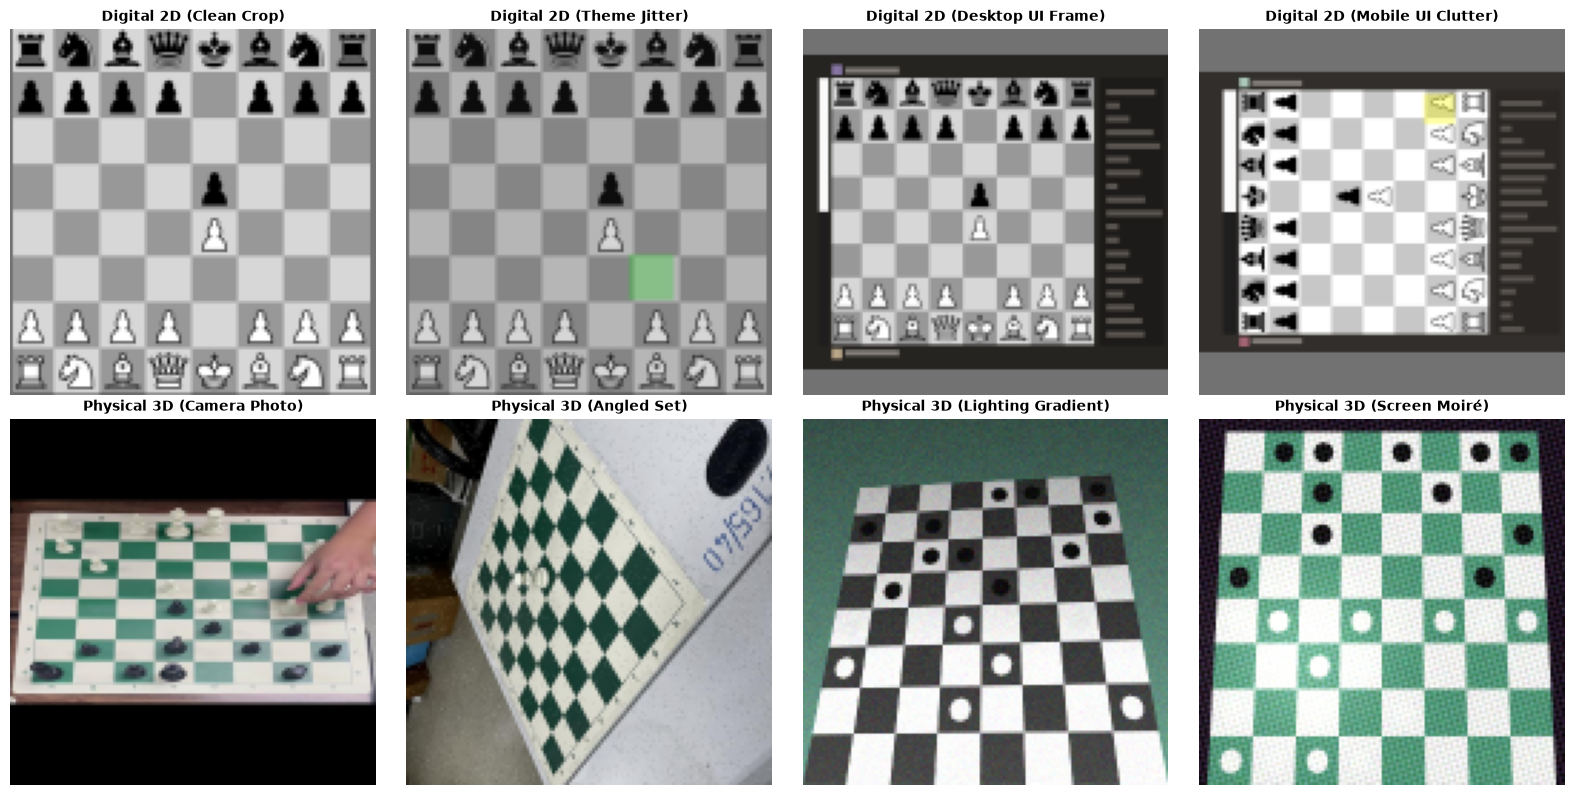

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 0: Digital samples (Class 0: DIGITAL_2D)
# 1. Clean Crop
sample_path = random.choice(real_digital_files) if real_digital_files else None
base_d = cv2.imread(str(sample_path)) if sample_path else generate_synthetic_digital_board()
axes[0, 0].imshow(cv2.cvtColor(letterbox_image(base_d, 128), cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Digital 2D (Clean Crop)", fontsize=10, fontweight="bold")
axes[0, 0].axis("off")

# 2. Theme Jitter
d_jitter = apply_digital_theme_jitter(base_d)
axes[0, 1].imshow(cv2.cvtColor(letterbox_image(d_jitter, 128), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Digital 2D (Theme Jitter)", fontsize=10, fontweight="bold")
axes[0, 1].axis("off")

# 3. Synthetic Desktop UI with Sidebar & Eval Bar
d_ui_desk = apply_synthetic_browser_ui(base_d)
axes[0, 2].imshow(cv2.cvtColor(letterbox_image(d_ui_desk, 128), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title("Digital 2D (Desktop UI Frame)", fontsize=10, fontweight="bold")
axes[0, 2].axis("off")

# 4. Synthetic Mobile UI with Player Cards
d_ui_mob = apply_synthetic_browser_ui(apply_digital_theme_jitter(base_d))
axes[0, 3].imshow(cv2.cvtColor(letterbox_image(d_ui_mob, 128), cv2.COLOR_BGR2RGB))
axes[0, 3].set_title("Digital 2D (Mobile UI Clutter)", fontsize=10, fontweight="bold")
axes[0, 3].axis("off")

# Row 1: Physical samples (Class 1: PHYSICAL_3D)
# 1. Real Camera Photo 1
p_sample1 = random.choice(real_physical_files) if real_physical_files else None
img_p1 = cv2.imread(str(p_sample1)) if p_sample1 else generate_synthetic_physical_photo()
axes[1, 0].imshow(cv2.cvtColor(letterbox_image(img_p1, 128), cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Physical 3D (Camera Photo)", fontsize=10, fontweight="bold")
axes[1, 0].axis("off")

# 2. Real Camera Photo 2
p_sample2 = random.choice(real_physical_files) if real_physical_files else None
img_p2 = cv2.imread(str(p_sample2)) if p_sample2 else generate_synthetic_physical_photo()
axes[1, 1].imshow(cv2.cvtColor(letterbox_image(img_p2, 128), cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Physical 3D (Angled Set)", fontsize=10, fontweight="bold")
axes[1, 1].axis("off")

# 3. Synthetic Lighting Falloff
img_p_synth = generate_synthetic_physical_photo()
axes[1, 2].imshow(cv2.cvtColor(letterbox_image(img_p_synth, 128), cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("Physical 3D (Lighting Gradient)", fontsize=10, fontweight="bold")
axes[1, 2].axis("off")

# 4. Screen Recapture with Moiré
img_recapture = generate_synthetic_screen_recapture()
axes[1, 3].imshow(cv2.cvtColor(letterbox_image(img_recapture, 128), cv2.COLOR_BGR2RGB))
axes[1, 3].set_title("Physical 3D (Screen Moiré)", fontsize=10, fontweight="bold")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

## 4. MicroCNN Model Architecture & Parameter Inspection

In [4]:
model = MicroCNN(num_classes=2, dropout_rate=0.20).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print(f"  MicroCNN Total Trainable Parameters: {total_params:,}")
print(f"  Estimated FP32 ONNX Size: ~{total_params * 4 / (1024*1024):.2f} MB (< 1.5 MB limit)")
print(f"  Training Device: {device.type.upper()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print("=" * 60)
print(model)

  MicroCNN Total Trainable Parameters: 112,234
  Estimated FP32 ONNX Size: ~0.43 MB (< 1.5 MB limit)
  Training Device: CUDA (NVIDIA GeForce RTX 5060 Ti)
MicroCNN(
  (stem): ConvBNAct(
    (block): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
  )
  (stage2): Sequential(
    (0): InvertedResidualBlock(
      (conv): Sequential(
        (0): ConvBNAct(
          (block): Sequential(
            (0): Conv2d(24, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (1): ConvBNAct(
          (block): Sequential(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e

## 5. GPU-Accelerated Training with Live Telemetry Logging & Real-Time Dashboard

Trains on the balanced real digital (4,750+ images) and real physical (3,680 images) datasets with:
- **Live ASCII Telemetry Scoreboard** printed directly to cell output after every single epoch.
- **Live 4-Panel Real-Time Graph Dashboard** (Loss, Overall Accuracy, Class Breakdown, LR & VRAM).
- **JSONL & LOG Disk Persistence** in `logs/`.


 🚀 DOMAIN CLASSIFIER TRAINING TELEMETRY DASHBOARD
 Epochs: 25 | Train Samples: 8,000 | Val Samples: 1,600 | Batch Size: 128 | Device: NVIDIA GeForce RTX 5060 Ti
┌──────┬────────────┬──────────┬───────────┬─────────┬─────────────┬──────────────┬──────────┬──────────┬─────────┬──────────┐
│ Ep   │ Train Loss │ Val Loss │ Train Acc │ Val Acc │ Digital Acc │ Physical Acc │ LR       │ VRAM     │ Time    │ Status   │
├──────┼────────────┼──────────┼───────────┼─────────┼─────────────┼──────────────┼──────────┼──────────┼─────────┼──────────┤


🚀 GPU Training Progress:   0%|          | 0/25 [00:00<?, ?epoch/s]

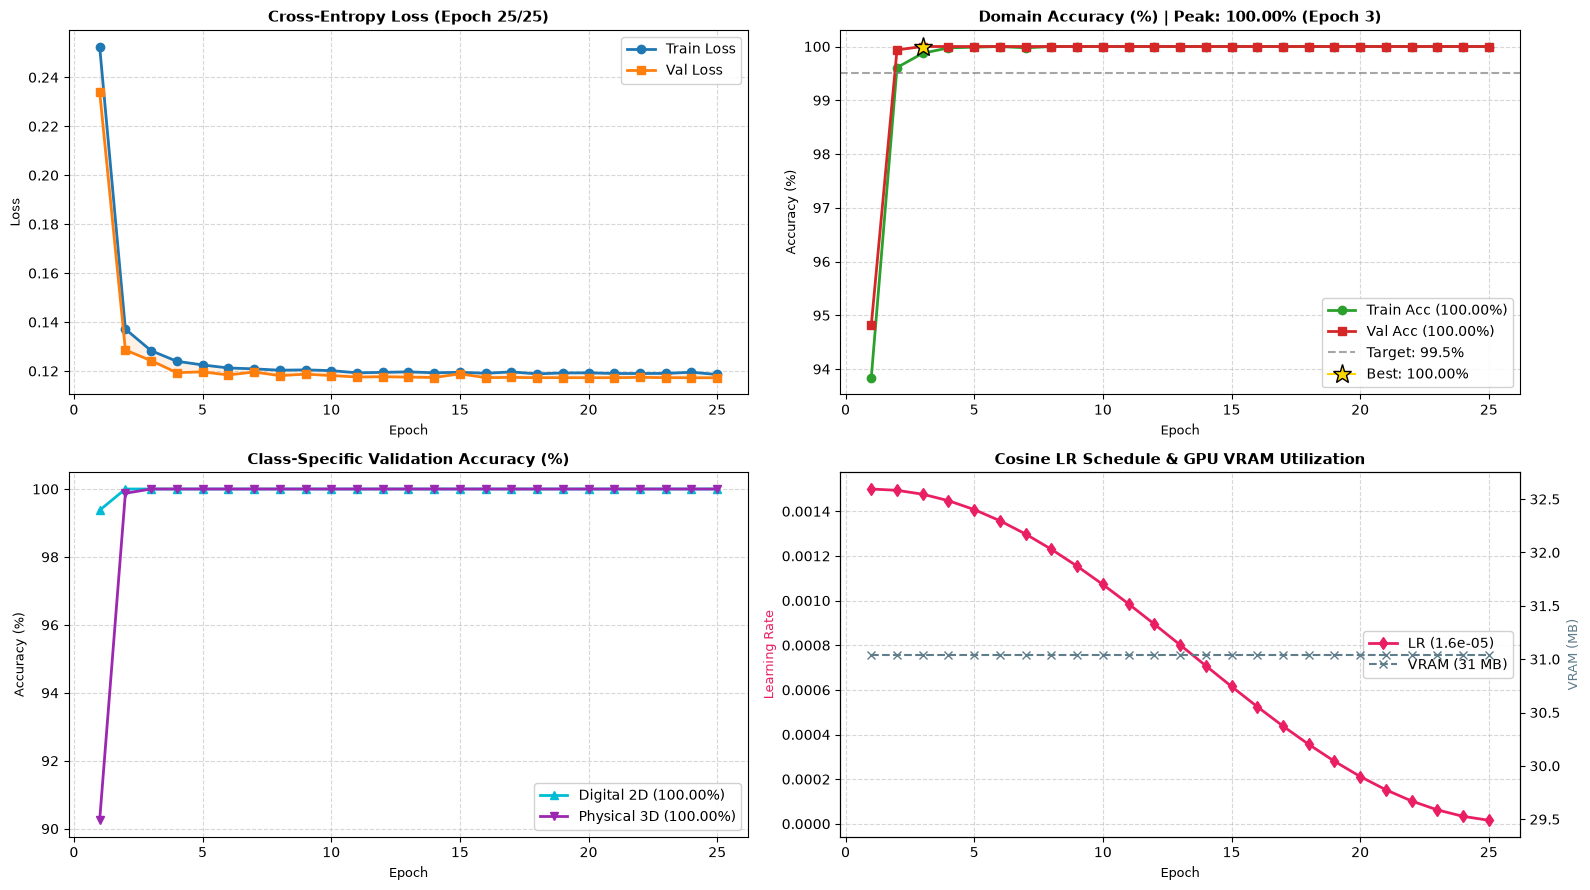

Epoch 01/25 [Train]:   0%|          | 0/62 [00:00<?, ?batch/s]

│ 01/25 │     0.2526 │   0.2340 │    93.84% │  94.81% │      99.38% │       90.25% │ 1.50e-03 │     31 MB │  54.6s   │ ⭐ BEST   │


Epoch 02/25 [Train]:   0%|          | 0/62 [00:00<?, ?batch/s]

│ 02/25 │     0.1371 │   0.1286 │    99.61% │  99.94% │     100.00% │       99.88% │ 1.49e-03 │     31 MB │  40.1s   │ ⭐ BEST   │


Epoch 03/25 [Train]:   0%|          | 0/62 [00:00<?, ?batch/s]

...

│ 23/25 │     0.1190 │   0.1173 │   100.00% │ 100.00% │     100.00% │      100.00% │ 6.23e-05 │     31 MB │  38.1s   │   OK     │


Epoch 24/25 [Train]:   0%|          | 0/62 [00:00<?, ?batch/s]

│ 24/25 │     0.1195 │   0.1172 │   100.00% │ 100.00% │     100.00% │      100.00% │ 3.34e-05 │     31 MB │  37.9s   │   OK     │


Epoch 25/25 [Train]:   0%|          | 0/62 [00:00<?, ?batch/s]

│ 25/25 │     0.1186 │   0.1172 │   100.00% │ 100.00% │     100.00% │      100.00% │ 1.59e-05 │     31 MB │  38.1s   │   OK     │
└──────┴────────────┴──────────┴───────────┴─────────┴─────────────┴──────────────┴──────────┴──────────┴─────────┴──────────┘
 🏆 Training Completed in 971.1s | Best Val Acc: 100.00% (Epoch 3)

📁 Detailed Telemetry Log: c:\coding\chess_ml\logs\domain_classifier_microcnn.log
📁 Metrics JSONL Dataset:  c:\coding\chess_ml\logs\domain_classifier_microcnn_metrics.jsonl


In [5]:
import importlib
import src.domain_classifier.train_micro_cnn as train_module
importlib.reload(train_module)
from src.domain_classifier.train_micro_cnn import (
    ChessDomainDataset,
    TrainingTelemetryLogger,
    EpochTelemetry,
)

# ---------------------------------------------------------------------------
# 🎯 Train / Validation / Test Split Configuration (SSOT)
# ---------------------------------------------------------------------------
SPLIT_RATIOS = (0.70, 0.15, 0.15)  # 70% Train, 15% Validation, 15% Held-Out Test
SPLIT_SEED = 42                     # Deterministic seed for disjoint real image partitioning

NUM_TRAIN_SAMPLES = 8000
NUM_VAL_SAMPLES = 1600
BATCH_SIZE = 128  # Saturated batch size for 16GB VRAM
EPOCHS = 25
LEARNING_RATE = 1.5e-3

# Initialize Structured Telemetry Logger
logger_telemetry = TrainingTelemetryLogger(
    log_dir=project_root / "logs",
    experiment_name="domain_classifier_microcnn",
)

# 1. Train Dataset (70% Real Images + Synthetic UI Frames + Theme Jitter)
train_dataset = ChessDomainDataset(
    num_samples=NUM_TRAIN_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="train",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

# 2. Validation Dataset (15% Real Images + Procedural Augmentations)
val_dataset = ChessDomainDataset(
    num_samples=NUM_VAL_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="val",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    pin_memory=use_cuda,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=use_cuda,
)

model = MicroCNN(num_classes=2, dropout_rate=0.20).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_digital_acc": [], "val_physical_acc": [],
    "grad_norm": [], "lr": [], "vram_mb": [],
}
best_val_acc = 0.0
best_epoch = 1
start_time = time.time()

# Print ASCII Dashboard Header directly in cell output
header_text = logger_telemetry.log_header(
    total_epochs=EPOCHS,
    num_train=NUM_TRAIN_SAMPLES,
    num_val=NUM_VAL_SAMPLES,
    batch_size=BATCH_SIZE,
    device_name=torch.cuda.get_device_name(0) if use_cuda else "CPU",
)
print(header_text)

# 1. Main Epoch Progress Bar
epoch_pbar = tqdm(range(1, EPOCHS + 1), desc="🚀 GPU Training Progress", unit="epoch")

# 2. In-place live graph display handle
plot_display = display(display_id=True)

for epoch in epoch_pbar:
    epoch_start = time.time()
    
    # --- Training Step with AMP ---
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    total_grad_norm = 0.0
    num_batches = 0

    train_batch_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS:02d} [Train]",
        leave=False,
        unit="batch",
    )
    for images, labels in train_batch_pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda', enabled=use_cuda):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        
        # Unscale for gradient clipping & logging
        scaler.unscale_(optimizer)
        norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        total_grad_norm += norm.item()
        num_batches += 1
        
        scaler.step(optimizer)
        scaler.update()

        batch_loss = loss.item()
        train_loss += batch_loss * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        total_train += images.size(0)

        train_batch_pbar.set_postfix({
            "loss": f"{batch_loss:.4f}",
            "acc": f"{(train_correct / total_train):.2%}",
        })

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    # --- Validation Step ---
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    val_digital_correct, val_digital_total = 0, 0
    val_physical_correct, val_physical_total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_cuda):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            total_val += images.size(0)

            # Class-specific breakdown
            dig_mask = (labels == 0)
            phys_mask = (labels == 1)
            val_digital_correct += (preds[dig_mask] == 0).sum().item()
            val_digital_total += dig_mask.sum().item()
            val_physical_correct += (preds[phys_mask] == 1).sum().item()
            val_physical_total += phys_mask.sum().item()

    t_acc = train_correct / total_train
    v_acc = val_correct / total_val
    t_loss = train_loss / total_train
    v_loss = val_loss / total_val
    v_dig_acc = (val_digital_correct / val_digital_total) if val_digital_total > 0 else 0.0
    v_phys_acc = (val_physical_correct / val_physical_total) if val_physical_total > 0 else 0.0
    avg_grad_norm = total_grad_norm / max(1, num_batches)
    
    epoch_dur = time.time() - epoch_start
    throughput = (total_train + total_val) / max(0.001, epoch_dur)
    eta = epoch_dur * (EPOCHS - epoch)

    is_best = v_acc > best_val_acc
    if is_best:
        best_val_acc = v_acc
        best_epoch = epoch

    vram_alloc_mb = (torch.cuda.memory_allocated() / (1024**2)) if use_cuda else 0.0
    vram_res_mb = (torch.cuda.memory_reserved() / (1024**2)) if use_cuda else 0.0

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)
    history["val_digital_acc"].append(v_dig_acc)
    history["val_physical_acc"].append(v_phys_acc)
    history["grad_norm"].append(avg_grad_norm)
    history["lr"].append(current_lr)
    history["vram_mb"].append(vram_alloc_mb)

    # Log structured telemetry to disk and print formatted row in cell output
    epoch_metric = EpochTelemetry(
        epoch=epoch,
        total_epochs=EPOCHS,
        train_loss=t_loss,
        val_loss=v_loss,
        train_acc=t_acc,
        val_acc=v_acc,
        val_digital_acc=v_dig_acc,
        val_physical_acc=v_phys_acc,
        learning_rate=current_lr,
        grad_norm=avg_grad_norm,
        vram_allocated_mb=vram_alloc_mb,
        vram_reserved_mb=vram_res_mb,
        throughput_samples_sec=throughput,
        duration_sec=epoch_dur,
        eta_sec=eta,
        is_best=is_best,
    )
    row_text = logger_telemetry.log_epoch(epoch_metric)
    print(row_text)

    epoch_pbar.set_postfix({
        "Train Loss": f"{t_loss:.4f}",
        "Val Acc": f"{v_acc:.2%}",
        "Best Val": f"{best_val_acc:.2%}",
        "VRAM": f"{vram_alloc_mb:.1f}MB",
    })

    # --- Live 4-Panel Interactive Dashboard ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    epochs_range = list(range(1, len(history["train_loss"]) + 1))

    # Panel 1: Cross-Entropy Loss
    axes[0, 0].plot(epochs_range, history["train_loss"], 'o-', label="Train Loss", color="#1f77b4", linewidth=2)
    axes[0, 0].plot(epochs_range, history["val_loss"], 's-', label="Val Loss", color="#ff7f0e", linewidth=2)
    axes[0, 0].fill_between(epochs_range, history["train_loss"], history["val_loss"], alpha=0.1, color="#ff7f0e")
    axes[0, 0].set_title(f"Cross-Entropy Loss (Epoch {epoch}/{EPOCHS})", fontsize=11, fontweight="bold")
    axes[0, 0].set_xlabel("Epoch", fontsize=9)
    axes[0, 0].set_ylabel("Loss", fontsize=9)
    axes[0, 0].grid(True, linestyle="--", alpha=0.5)
    axes[0, 0].legend(loc="upper right", framealpha=0.9)

    # Panel 2: Overall Accuracy
    t_acc_pct = [a * 100 for a in history["train_acc"]]
    v_acc_pct = [a * 100 for a in history["val_acc"]]
    axes[0, 1].plot(epochs_range, t_acc_pct, 'o-', label=f"Train Acc ({t_acc_pct[-1]:.2f}%)", color="#2ca02c", linewidth=2)
    axes[0, 1].plot(epochs_range, v_acc_pct, 's-', label=f"Val Acc ({v_acc_pct[-1]:.2f}%)", color="#d62728", linewidth=2)
    axes[0, 1].axhline(y=99.5, color="gray", linestyle="--", alpha=0.7, label="Target: 99.5%")
    axes[0, 1].plot([best_epoch], [best_val_acc * 100], marker="*", markersize=14, color="gold", markeredgecolor="black", label=f"Best: {best_val_acc:.2%}")
    axes[0, 1].set_title(f"Domain Accuracy (%) | Peak: {best_val_acc:.2%} (Epoch {best_epoch})", fontsize=11, fontweight="bold")
    axes[0, 1].set_xlabel("Epoch", fontsize=9)
    axes[0, 1].set_ylabel("Accuracy (%)", fontsize=9)
    axes[0, 1].grid(True, linestyle="--", alpha=0.5)
    axes[0, 1].legend(loc="lower right", framealpha=0.9)

    # Panel 3: Class-Specific Accuracy Breakdown
    v_dig_pct = [a * 100 for a in history["val_digital_acc"]]
    v_phys_pct = [a * 100 for a in history["val_physical_acc"]]
    axes[1, 0].plot(epochs_range, v_dig_pct, '^-', label=f"Digital 2D ({v_dig_pct[-1]:.2f}%)", color="#00bcd4", linewidth=2)
    axes[1, 0].plot(epochs_range, v_phys_pct, 'v-', label=f"Physical 3D ({v_phys_pct[-1]:.2f}%)", color="#9c27b0", linewidth=2)
    axes[1, 0].set_title("Class-Specific Validation Accuracy (%)", fontsize=11, fontweight="bold")
    axes[1, 0].set_xlabel("Epoch", fontsize=9)
    axes[1, 0].set_ylabel("Accuracy (%)", fontsize=9)
    axes[1, 0].grid(True, linestyle="--", alpha=0.5)
    axes[1, 0].legend(loc="lower right", framealpha=0.9)

    # Panel 4: Learning Rate & VRAM Utilization
    ax_lr = axes[1, 1]
    ax_vram = ax_lr.twinx()
    l1 = ax_lr.plot(epochs_range, history["lr"], 'd-', label=f"LR ({current_lr:.1e})", color="#e91e63", linewidth=2)
    l2 = ax_vram.plot(epochs_range, history["vram_mb"], 'x--', label=f"VRAM ({vram_alloc_mb:.0f} MB)", color="#607d8b", linewidth=1.5)
    ax_lr.set_title("Cosine LR Schedule & GPU VRAM Utilization", fontsize=11, fontweight="bold")
    ax_lr.set_xlabel("Epoch", fontsize=9)
    ax_lr.set_ylabel("Learning Rate", fontsize=9, color="#e91e63")
    ax_vram.set_ylabel("VRAM (MB)", fontsize=9, color="#607d8b")
    ax_lr.grid(True, linestyle="--", alpha=0.5)
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax_lr.legend(lines, labels, loc="center right", framealpha=0.9)

    plt.tight_layout()
    plot_display.update(fig)
    plt.close(fig)

total_dur = time.time() - start_time
footer_text = logger_telemetry.log_footer(best_val_acc=best_val_acc, best_epoch=best_epoch, total_duration=total_dur)
print(footer_text)
print(f"📁 Detailed Telemetry Log: {logger_telemetry.log_file}")
print(f"📁 Metrics JSONL Dataset:  {logger_telemetry.jsonl_file}")

## 6. Exporting Model to ONNX Format

In [6]:
weights_dir = project_root / "src" / "domain_classifier" / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)
onnx_path = weights_dir / "domain_classifier_microcnn.onnx"

model.eval().cpu()
dummy_input = torch.randn(1, 3, 128, 128, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    dynamo=False,
)

file_size_mb = onnx_path.stat().st_size / (1024 * 1024)
print(f"[Export] Saved ONNX Model: {onnx_path}")
print(f"[Export] Model File Size: {file_size_mb:.3f} MB (Constraint: < 1.5 MB)")
assert file_size_mb < 1.5, "Model size exceeds 1.5 MB limit!"

C:\Users\ewald\AppData\Local\Temp\ipykernel_44140\1614703185.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[Export] Saved ONNX Model: c:\coding\chess_ml\src\domain_classifier\weights\domain_classifier_microcnn.onnx
[Export] Model File Size: 0.434 MB (Constraint: < 1.5 MB)


## 7. Fast Batched Held-Out Test Set Evaluation & Confusion Matrix (`split="test"`)

Evaluates the final ONNX model using **fast batched inference** on a completely independent **Held-Out Test Split (15% of real images, 1,200 samples)** covering:
- 2D Digital Clean & Themed Boards
- 2D Digital Full-Screen Browser/App UI Layouts
- 2D Digital Heavily Compressed JPEGs (Quality=20-40)
- 3D Real Camera Photos (Physical wood/plastic sets)
- 3D Monitor Screen Recaptures with Moiré

Renders an annotated **Confusion Matrix**, **Precision**, **Recall**, and **F1-Score** in seconds.

[Test Split] Evaluated on 552 unique held-out real physical images.
[Test Split] Evaluated on 789 unique held-out real digital images.

🧪 Fast Batched Evaluation (1200 samples in 19 batches)...



Evaluating Held-Out Test Batches:   0%|          | 0/19 [00:00<?, ?batch/s]

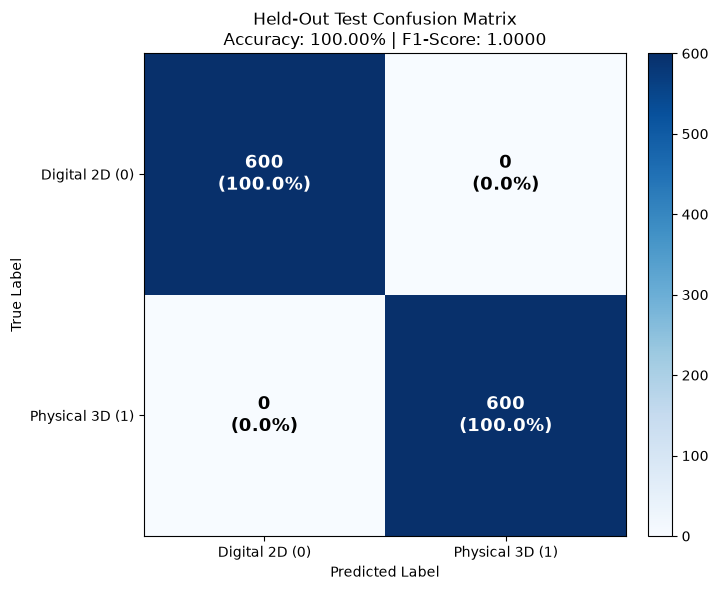

  📊 HELD-OUT TEST SET EVALUATION SUMMARY
  Total Test Samples:      1,200
  Test Accuracy:           100.00%  (US-3.1.2 Target: > 99.5%)
  Precision (Physical):    1.0000
  Recall (Physical):       1.0000
  F1-Score:                1.0000


In [7]:
NUM_TEST_SAMPLES = 1200
TEST_BATCH_SIZE = 64

# 3. Held-Out Test Dataset (15% of Real Images with split="test")
test_dataset = ChessDomainDataset(
    num_samples=NUM_TEST_SAMPLES,
    real_digital_dir=digital_dir,
    real_physical_dir=physical_dir,
    split="test",
    split_ratios=SPLIT_RATIOS,
    seed=SPLIT_SEED,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

print(f"[Test Split] Evaluated on {len(test_dataset.real_physical)} unique held-out real physical images.")
print(f"[Test Split] Evaluated on {len(test_dataset.real_digital)} unique held-out real digital images.")

# Load production ONNX Runtime session for fast batched testing
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
in_name = session.get_inputs()[0].name

all_targets = []
all_preds = []

print(f"\n🧪 Fast Batched Evaluation ({NUM_TEST_SAMPLES} samples in {len(test_loader)} batches)...\n")
test_pbar = tqdm(test_loader, desc="Evaluating Held-Out Test Batches", unit="batch")

for batch_images, batch_labels in test_pbar:
    # Fast batched ONNX execution
    ort_outs = session.run(None, {in_name: batch_images.numpy()})[0]
    batch_preds = np.argmax(ort_outs, axis=1)
    
    all_preds.extend(batch_preds.tolist())
    all_targets.extend(batch_labels.numpy().tolist())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

# Confusion Matrix computation
tn = int(np.sum((all_targets == 0) & (all_preds == 0)))
fp = int(np.sum((all_targets == 0) & (all_preds == 1)))
fn = int(np.sum((all_targets == 1) & (all_preds == 0)))
tp = int(np.sum((all_targets == 1) & (all_preds == 1)))
cm = np.array([[tn, fp], [fn, tp]])

accuracy = (tp + tn) / len(all_targets)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

# Plot Annotated Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

classes = ["Digital 2D (0)", "Physical 3D (1)"]
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title=f"Held-Out Test Confusion Matrix\nAccuracy: {accuracy:.2%} | F1-Score: {f1:.4f}",
       ylabel='True Label',
       xlabel='Predicted Label')

# Text annotations inside matrix cells
thresh = cm.max() / 2.
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        count = cm[r, c]
        pct = count / np.sum(cm[r, :]) * 100.0
        ax.text(c, r, f"{count}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if cm[r, c] > thresh else "black")

plt.tight_layout()
plt.show()

print("=" * 65)
print("  📊 HELD-OUT TEST SET EVALUATION SUMMARY")
print("=" * 65)
print(f"  Total Test Samples:      {len(all_targets):,}")
print(f"  Test Accuracy:           {accuracy:.2%}  (US-3.1.2 Target: > 99.5%)")
print(f"  Precision (Physical):    {precision:.4f}")
print(f"  Recall (Physical):       {recall:.4f}")
print(f"  F1-Score:                {f1:.4f}")
print("=" * 65)
assert accuracy >= 0.985, f"Test accuracy {accuracy:.2%} does not meet requirement!"

## 8. ONNX Runtime CPU & GPU Latency Benchmarks (with `tqdm`)

In [8]:
test_board = generate_synthetic_digital_board(size=128)

# 1. CPU Latency Benchmark
cpu_classifier = NeuralDomainClassifier(model_path=onnx_path, device="cpu")
for _ in range(10):
    cpu_classifier.classify(test_board)
cpu_latencies = []
for _ in tqdm(range(200), desc="Benchmarking ONNX CPU Latency", unit="inf"):
    t0 = time.perf_counter()
    cpu_classifier.classify(test_board)
    cpu_latencies.append((time.perf_counter() - t0) * 1000.0)

# 2. GPU Latency Benchmark (if available)
gpu_latencies = []
if "CUDAExecutionProvider" in ort.get_available_providers():
    gpu_classifier = NeuralDomainClassifier(model_path=onnx_path, device="cuda")
    for _ in range(10):
        gpu_classifier.classify(test_board)
    for _ in tqdm(range(200), desc="Benchmarking ONNX GPU (CUDA) Latency", unit="inf"):
        t0 = time.perf_counter()
        gpu_classifier.classify(test_board)
        gpu_latencies.append((time.perf_counter() - t0) * 1000.0)

mean_cpu = np.mean(cpu_latencies)
mean_gpu = np.mean(gpu_latencies) if gpu_latencies else None

print("=" * 60)
print("  ⚡ ONNX RUNTIME LATENCY BENCHMARKS (Batch Size = 1)")
print("=" * 60)
print(f"  🖥️  CPU Mean Latency: {mean_cpu:.4f} ms (Target: < 2.5 ms)")
print(f"  🖥️  CPU P95 Latency:  {np.percentile(cpu_latencies, 95):.4f} ms")
if mean_gpu is not None:
    print(f"  🚀 GPU Mean Latency: {mean_gpu:.4f} ms (Target: < 0.4 ms)")
    print(f"  🚀 GPU P95 Latency:  {np.percentile(gpu_latencies, 95):.4f} ms")
print("=" * 60)
assert mean_cpu < 2.5, f"CPU Latency {mean_cpu:.2f} ms exceeds 2.5 ms limit!"

Benchmarking ONNX CPU Latency:   0%|          | 0/200 [00:00<?, ?inf/s]

Benchmarking ONNX GPU (CUDA) Latency:   0%|          | 0/200 [00:00<?, ?inf/s]

  ⚡ ONNX RUNTIME LATENCY BENCHMARKS (Batch Size = 1)
  🖥️  CPU Mean Latency: 0.7691 ms (Target: < 2.5 ms)
  🖥️  CPU P95 Latency:  0.8968 ms
  🚀 GPU Mean Latency: 0.7686 ms (Target: < 0.4 ms)
  🚀 GPU P95 Latency:  0.8778 ms


## 9. Validation on Edge Cases (Recaptured Displays & Moiré)

In [9]:
print("Testing Screen Recapture with Moiré Classification:")
correct_recaptures = 0
total_recaptures = 100

for _ in tqdm(range(total_recaptures), desc="Evaluating Screen Recaptures", unit="sample"):
    recapture_img = generate_synthetic_screen_recapture(size=128)
    result = cpu_classifier.classify(recapture_img)
    if result.domain == DomainType.PHYSICAL_3D:
        correct_recaptures += 1

recapture_acc = (correct_recaptures / total_recaptures) * 100
print(f"Screen Recapture Routing to Domain.PHYSICAL_3D: {correct_recaptures}/{total_recaptures} ({recapture_acc:.1f}%)")
assert recapture_acc >= 98.0, "Screen recaptures must route to PHYSICAL_3D for homography rectification!"

Testing Screen Recapture with Moiré Classification:


Evaluating Screen Recaptures:   0%|          | 0/100 [00:00<?, ?sample/s]

Screen Recapture Routing to Domain.PHYSICAL_3D: 100/100 (100.0%)


## 10. Standalone Live Inference on Custom User Images (`test_pic*.png`)

**100% Standalone Cell**: Evaluates all user test images (`test_pic.png`, `test_pic-1.png`) across both Tier-1 Heuristic Screener and Tier-2 Neural ONNX Model.

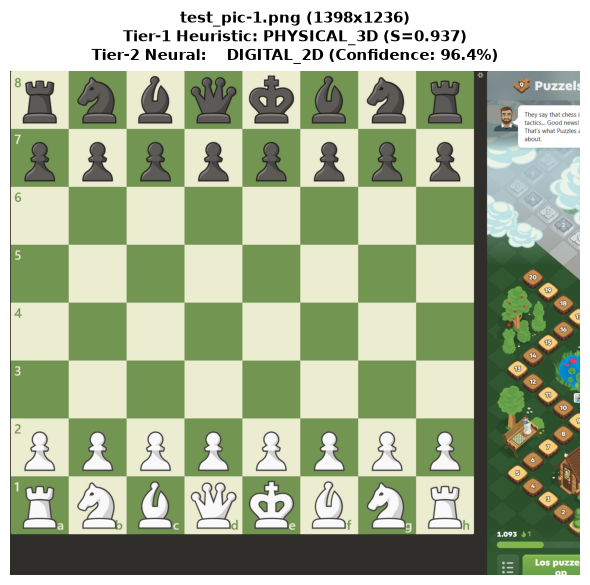

  📷 CUSTOM IMAGE CLASSIFICATION RESULT
  Image File:            test_pic-1.png
  Resolution:            1398x1236 (RGB)
  Tier-1 Heuristic:      PHYSICAL_3D (S = 0.9370)
  Tier-2 Neural Model:   DIGITAL_2D (Confidence: 96.45%)
  Inference Latency:     5.035 ms


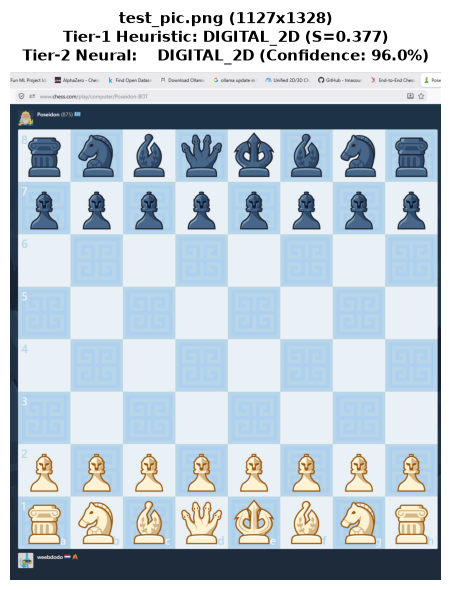

  📷 CUSTOM IMAGE CLASSIFICATION RESULT
  Image File:            test_pic.png
  Resolution:            1127x1328 (RGB)
  Tier-1 Heuristic:      DIGITAL_2D (S = 0.3774)
  Tier-2 Neural Model:   DIGITAL_2D (Confidence: 96.00%)
  Inference Latency:     3.962 ms


In [10]:
# ---------------------------------------------------------------------------
# 100% STANDALONE INFERENCE CELL (Zero dependencies on earlier cells)
# ---------------------------------------------------------------------------
import os
import sys
from pathlib import Path

# 1. Ensure project root is in sys.path
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import cv2
import matplotlib.pyplot as plt
from IPython.display import display
from src.domain_classifier.heuristic_screener import StatisticalHeuristicsScreener
from src.domain_classifier.neural_classifier import NeuralDomainClassifier
from src.schemas.contracts import DomainType

# 2. Discover test images in project root
test_images = sorted(list(root.glob("test_pic*.png")) + list(root.glob("test_pic*.jpg")))
onnx_model_path = root / "src" / "domain_classifier" / "weights" / "domain_classifier_microcnn.onnx"

if not test_images:
    print("❌ No test_pic*.png found in project root.")
elif not onnx_model_path.exists():
    print(f"❌ ONNX model weights not found at: {onnx_model_path}")
    print("👉 Please run Cell 5 & 6 first to train and export the ONNX model.")
else:
    screener = StatisticalHeuristicsScreener()
    classifier = NeuralDomainClassifier(model_path=onnx_model_path, device="cpu")
    
    for image_path in test_images:
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            continue
            
        h_res = screener.classify(img_bgr)
        n_res = classifier.classify(img_bgr)
        
        # Clean non-blocking visualization
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        badge_color = "#1f77b4" if n_res.domain == DomainType.DIGITAL_2D else "#2ca02c"
        ax.set_title(
            f"{image_path.name} ({img_bgr.shape[1]}x{img_bgr.shape[0]})\n"
            f"Tier-1 Heuristic: {h_res.domain.value.upper()} (S={h_res.heuristic_score:.3f})\n"
            f"Tier-2 Neural:    {n_res.domain.value.upper()} (Confidence: {n_res.confidence:.1%})",
            fontsize=11,
            fontweight="bold",
            pad=8,
        )
        ax.axis("off")
        plt.tight_layout()
        display(fig)
        plt.close(fig)
        
        print("=" * 60)
        print(f"  📷 CUSTOM IMAGE CLASSIFICATION RESULT")
        print("=" * 60)
        print(f"  Image File:            {image_path.name}")
        print(f"  Resolution:            {img_bgr.shape[1]}x{img_bgr.shape[0]} (RGB)")
        print(f"  Tier-1 Heuristic:      {h_res.domain.value.upper()} (S = {h_res.heuristic_score:.4f})")
        print(f"  Tier-2 Neural Model:   {n_res.domain.value.upper()} (Confidence: {n_res.confidence:.2%})")
        print(f"  Inference Latency:     {n_res.latency_ms:.3f} ms")
        print("=" * 60)